In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
%matplotlib inline

In [22]:
df = pd.read_csv('../data/fraudTrain.csv') 
test_df = pd.read_csv('../data/fraudTest.csv')

In [23]:
df.shape

(1296675, 23)

In [24]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [26]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [27]:

df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [28]:
df['is_fraud'].value_counts(normalize = True) *100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

In [29]:

df.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


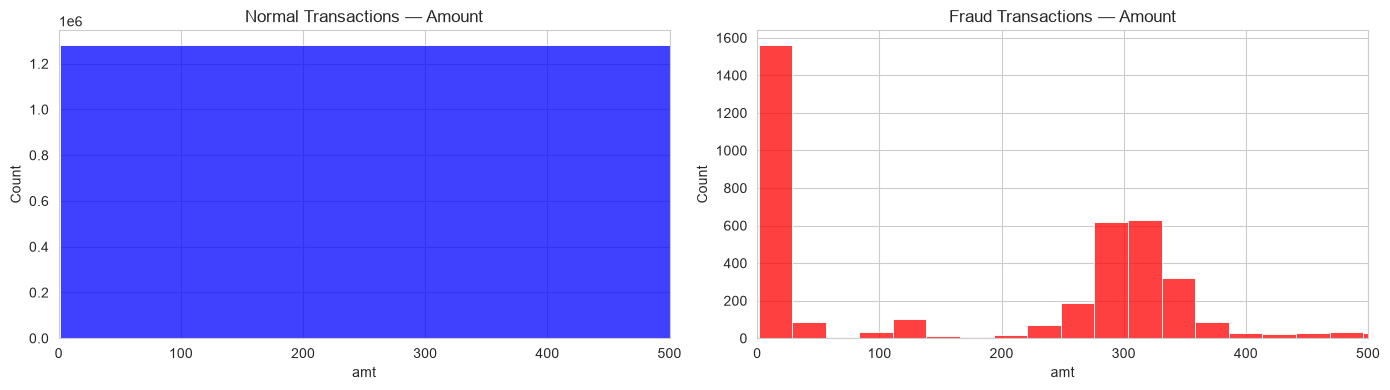

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[df['is_fraud'] == 0]['amt'], bins=50, ax=ax[0], color='blue')
ax[0].set_title('Normal Transactions — Amount')
ax[0].set_xlim(0, 500)

sns.histplot(df[df['is_fraud'] == 1]['amt'], bins=50, ax=ax[1], color='red')
ax[1].set_title('Fraud Transactions — Amount')
ax[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

In [31]:
df['amt'].value_counts()

amt
1.14      542
1.04      538
1.25      535
1.02      533
1.01      523
         ... 
571.71      1
223.71      1
754.81      1
374.71      1
255.52      1
Name: count, Length: 52928, dtype: int64

In [32]:
corr_with_class = df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)
print(corr_with_class)

is_fraud      1.000000
amt           0.219404
city_pop      0.002136
lat           0.001894
merch_lat     0.001741
merch_long    0.001721
long          0.001721
cc_num       -0.000981
zip          -0.002162
Unnamed: 0   -0.004767
unix_time    -0.005078
Name: is_fraud, dtype: float64


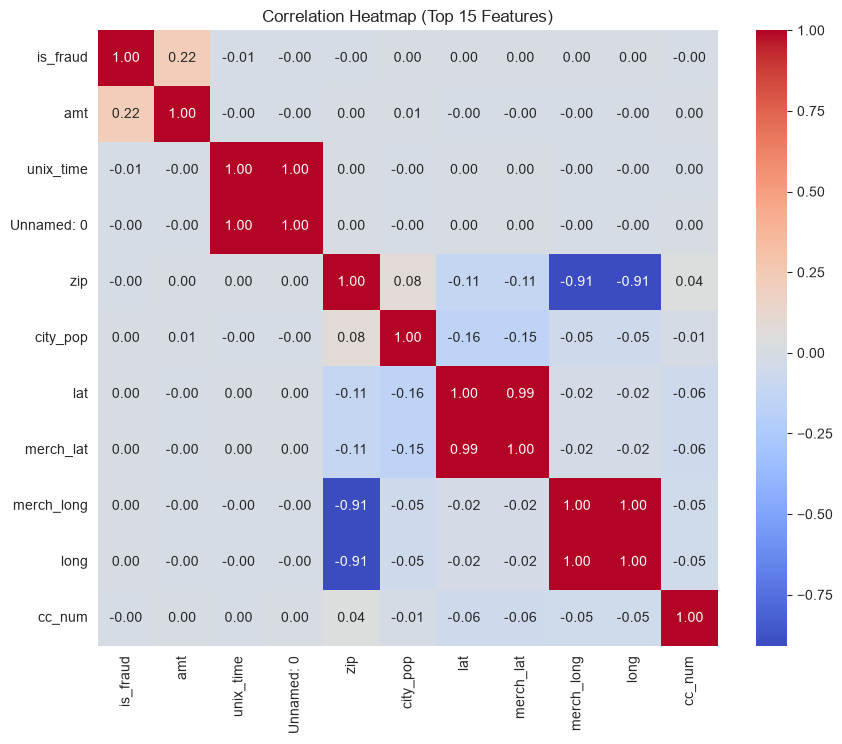

In [33]:
top_features = corr_with_class.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Top 15 Features)')

plt.show()

<Axes: ylabel='amt'>

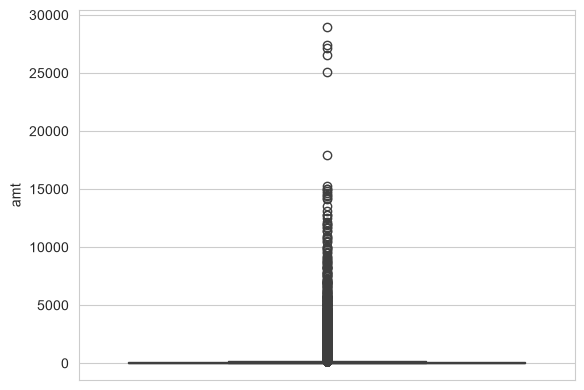

In [34]:
sns.boxplot(df['amt'])


In [35]:
print("Missing values:\n", df.isnull().sum().sum())

Missing values:
 0


In [36]:
# Reload raw data (before encoding)
df = pd.read_csv('../data/fraudTrain.csv')

# Identify column types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from numeric
numeric_cols = [c for c in numeric_cols if c != 'is_fraud']

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"\nNumeric: {numeric_cols}")
print(f"\nCategorical: {categorical_cols}")

Numeric columns: 10
Categorical columns: 12

Numeric: ['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']

Categorical: ['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


C:\Users\Vansh\AppData\Local\Temp\ipykernel_7180\488032214.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [37]:
def numeric_summary(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        rows.append({
            'column': col,
            'count': len(s),
            'missing': df[col].isnull().sum(),
            'mean': s.mean(),
            'median': s.median(),
            'std': s.std(),
            'min': s.min(),
            'max': s.max(),
            'skewness': s.skew(),
            'kurtosis': s.kurtosis(),
            'unique': s.nunique()
        })
    return pd.DataFrame(rows).round(3)

num_summary = numeric_summary(df, numeric_cols)
num_summary = num_summary.sort_values('skewness', key=abs, ascending=False)
print(num_summary.to_string(index=False))

    column   count  missing          mean        median          std           min           max  skewness  kurtosis  unique
       amt 1296675        0  7.035100e+01  4.752000e+01 1.603160e+02  1.000000e+00  2.894890e+04    42.278  4545.645   52928
  city_pop 1296675        0  8.882444e+04  2.456000e+03 3.019564e+05  2.300000e+01  2.906700e+06     5.594    37.615     879
    cc_num 1296675        0  4.171920e+17  3.521417e+15 1.308806e+18  6.041621e+10  4.992346e+18     2.852     6.180     983
      long 1296675        0 -9.022600e+01 -8.747700e+01 1.375900e+01 -1.656720e+02 -6.795000e+01    -1.150     1.856     969
merch_long 1296675        0 -9.022600e+01 -8.743800e+01 1.377100e+01 -1.666710e+02 -6.695100e+01    -1.147     1.848 1275745
       lat 1296675        0  3.853800e+01  3.935400e+01 5.076000e+00  2.002700e+01  6.669300e+01    -0.186     0.813     968
 merch_lat 1296675        0  3.853700e+01  3.936600e+01 5.110000e+00  1.902800e+01  6.751000e+01    -0.182     0.796 1247805


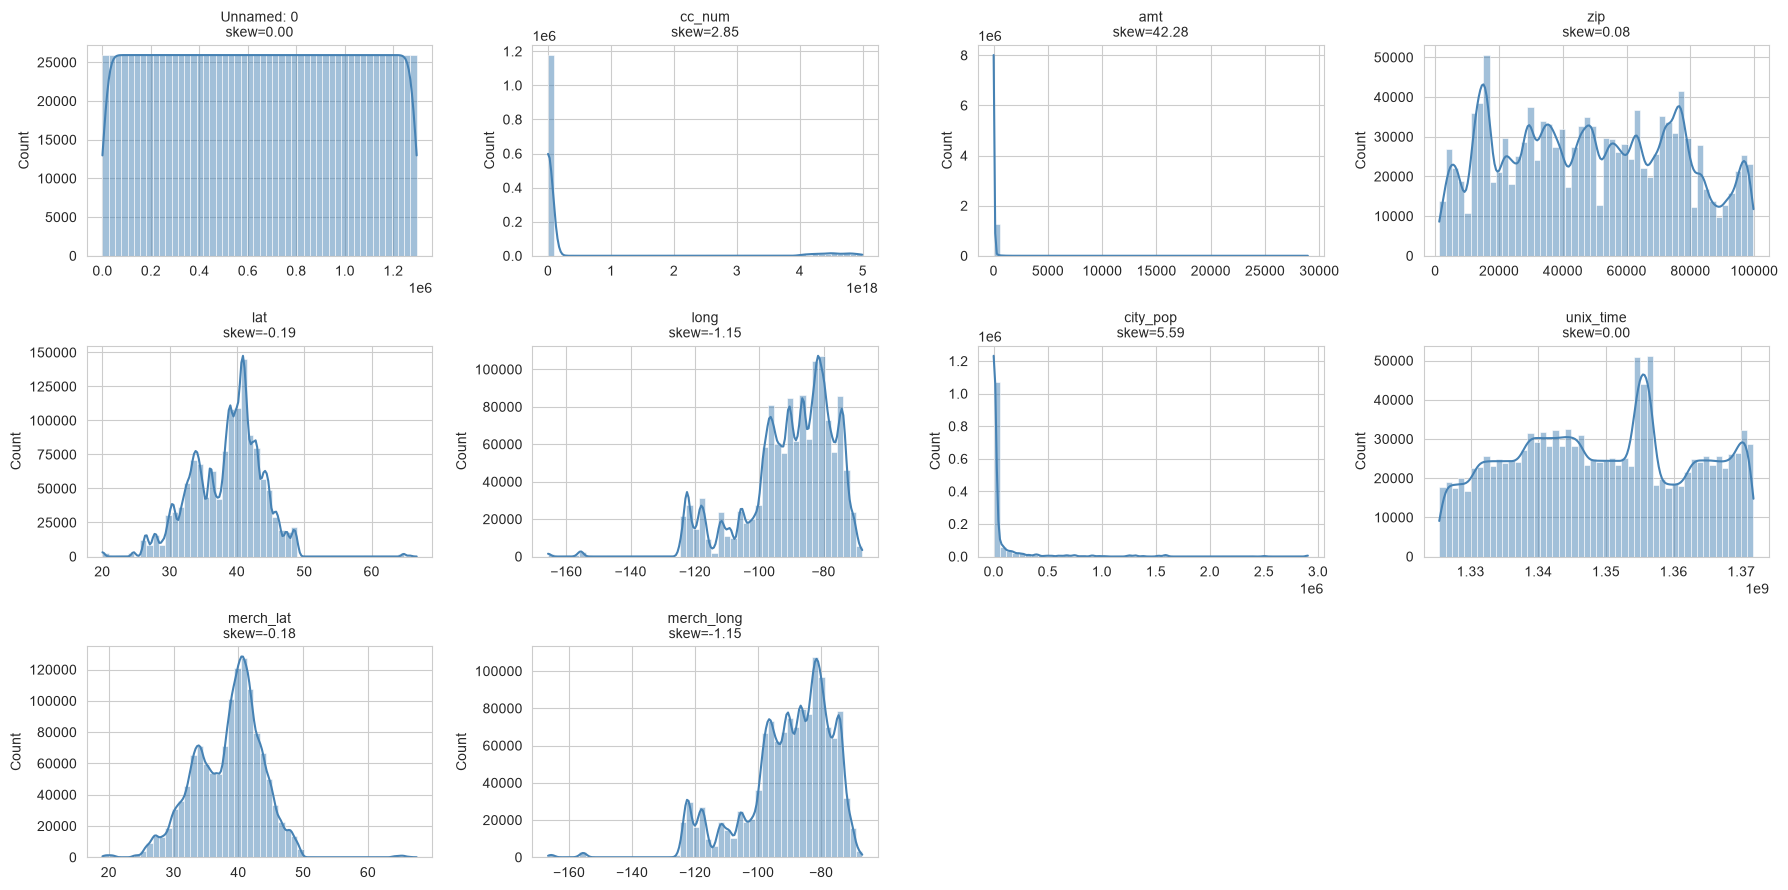

In [38]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4   # 4 plots per row

fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=50, ax=axes[i], kde=True, color='steelblue')
    skew_val = df[col].skew()
    axes[i].set_title(f"{col}\nskew={skew_val:.2f}", fontsize=10)
    axes[i].set_xlabel("")

# Hide empty subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

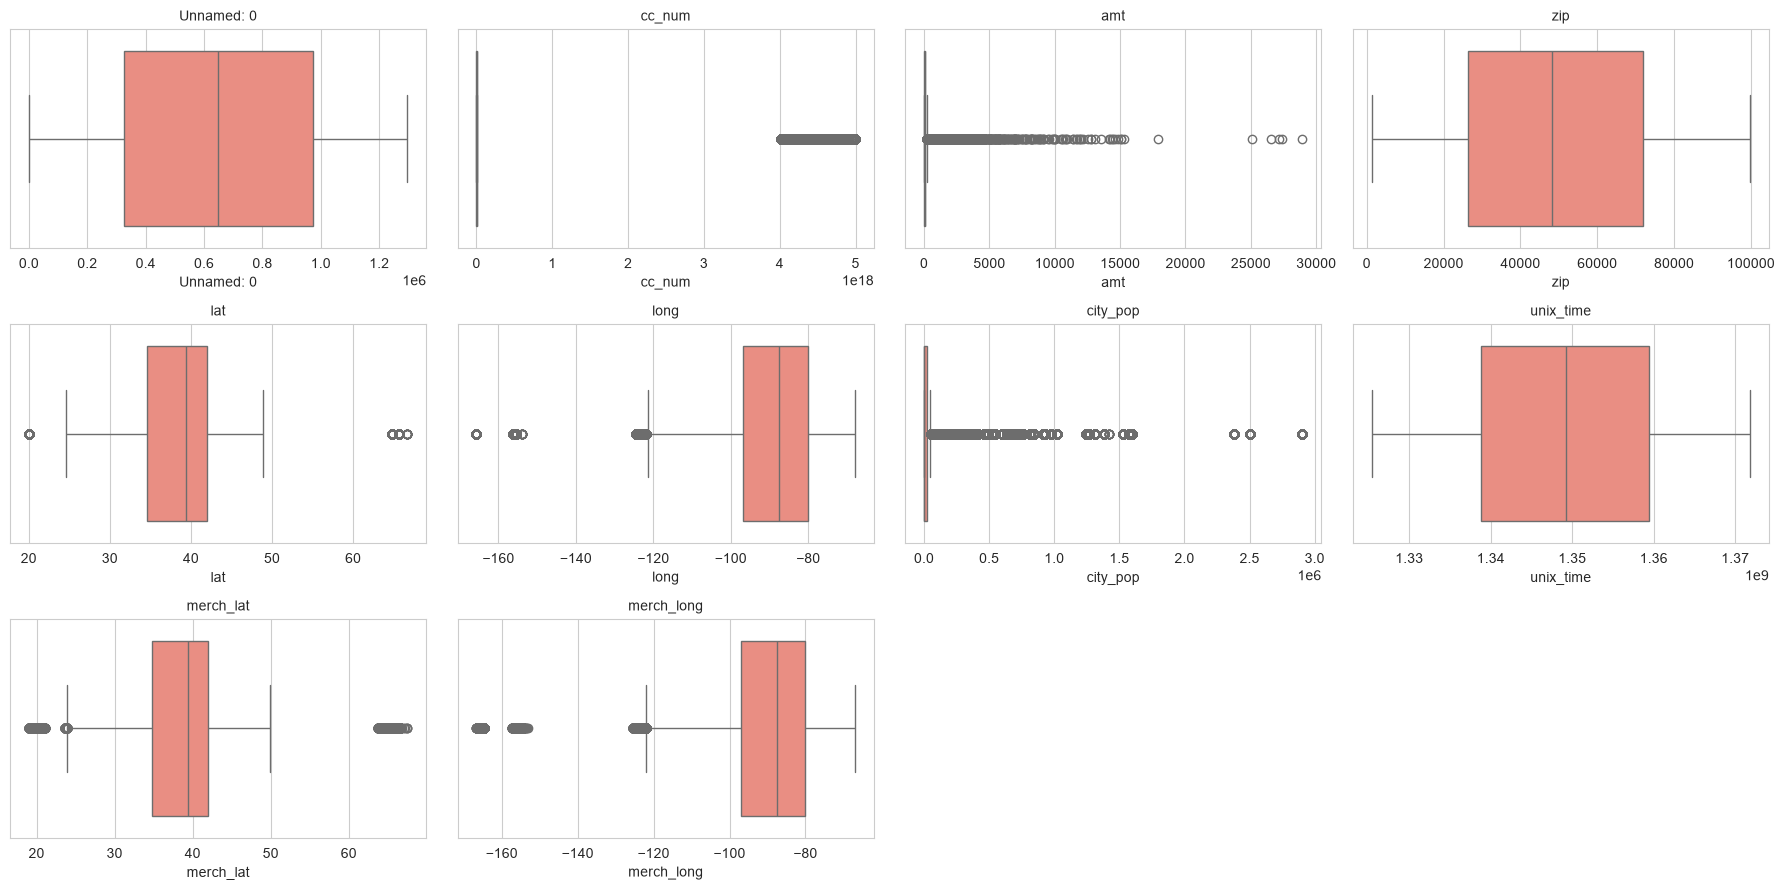

In [39]:
fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f"{col}", fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [40]:
def categorical_summary(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        top = s.value_counts().head(1)
        rows.append({
            'column': col,
            'unique': s.nunique(),
            'missing': df[col].isnull().sum(),
            'top_value': top.index[0] if len(top) else None,
            'top_count': int(top.values[0]) if len(top) else 0,
            'top_%': round(100 * top.values[0] / len(s), 2) if len(top) else 0
        })
    return pd.DataFrame(rows).round(2)

cat_summary = categorical_summary(df, categorical_cols)
cat_summary = cat_summary.sort_values('unique', ascending=False)
print(cat_summary.to_string(index=False))

               column  unique  missing                        top_value  top_count  top_%
            trans_num 1296675        0 0b242abb623afc578575680df30655b9          1   0.00
trans_date_trans_time 1274791        0              2019-04-22 16:02:01          4   0.00
               street     983        0              864 Reynolds Plains       3123   0.24
                  dob     968        0                       1977-03-23       5636   0.43
                 city     894        0                       Birmingham       5617   0.43
             merchant     693        0                fraud_Kilback LLC       4403   0.34
                  job     494        0                Film/video editor       9779   0.75
                 last     481        0                            Smith      28794   2.22
                first     352        0                      Christopher      26669   2.06
                state      51        0                               TX      94876   7.32
          

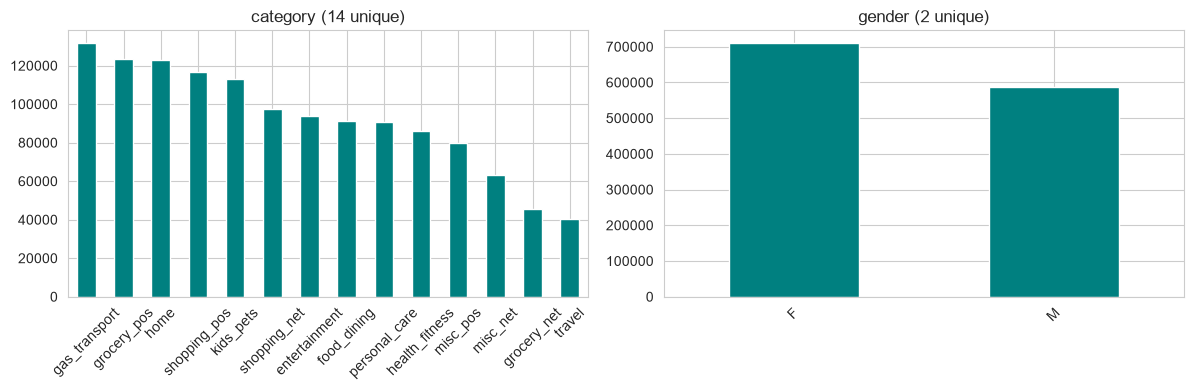

In [41]:
# Only plot columns with < 20 unique values
low_card_cols = [c for c in categorical_cols if df[c].nunique() < 20]

if low_card_cols:
    n = len(low_card_cols)
    n_rows_cat = (n + 2) // 3
    fig, axes = plt.subplots(n_rows_cat, 3, figsize=(18, n_rows_cat * 4))
    axes = axes.flatten() if n > 1 else [axes]
    
    for i, col in enumerate(low_card_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i], color='teal')
        axes[i].set_title(f"{col} ({df[col].nunique()} unique)")
        axes[i].set_xlabel("")
        axes[i].tick_params(axis='x', rotation=45)
    
    for j in range(len(low_card_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [42]:
# Fraud rate by each categorical column
for col in ['category', 'gender', 'state']:
    if col in df.columns:
        stats_df = df.groupby(col)['is_fraud'].agg(['mean', 'count'])
        stats_df['mean'] = (stats_df['mean'] * 100).round(2)
        stats_df = stats_df[stats_df['count'] > 100]  # skip rare
        stats_df = stats_df.sort_values('mean', ascending=False)
        stats_df.columns = ['Fraud Rate (%)', 'Count']
        
        print(f"\n=== Fraud Rate by {col} (top 10) ===")
        print(stats_df.head(10))


=== Fraud Rate by category (top 10) ===
               Fraud Rate (%)   Count
category                             
shopping_net             1.76   97543
misc_net                 1.45   63287
grocery_pos              1.41  123638
shopping_pos             0.72  116672
gas_transport            0.47  131659
misc_pos                 0.31   79655
travel                   0.29   40507
grocery_net              0.29   45452
entertainment            0.25   94014
personal_care            0.24   90758

=== Fraud Rate by gender (top 10) ===
        Fraud Rate (%)   Count
gender                        
M                 0.64  586812
F                 0.53  709863

=== Fraud Rate by state (top 10) ===
       Fraud Rate (%)  Count
state                       
RI               2.73    550
AK               1.70   2120
NV               0.84   5607
CO               0.81  13880
TN               0.80  17554
OR               0.80  18597
NE               0.74  24168
ME               0.72  16505
NH          

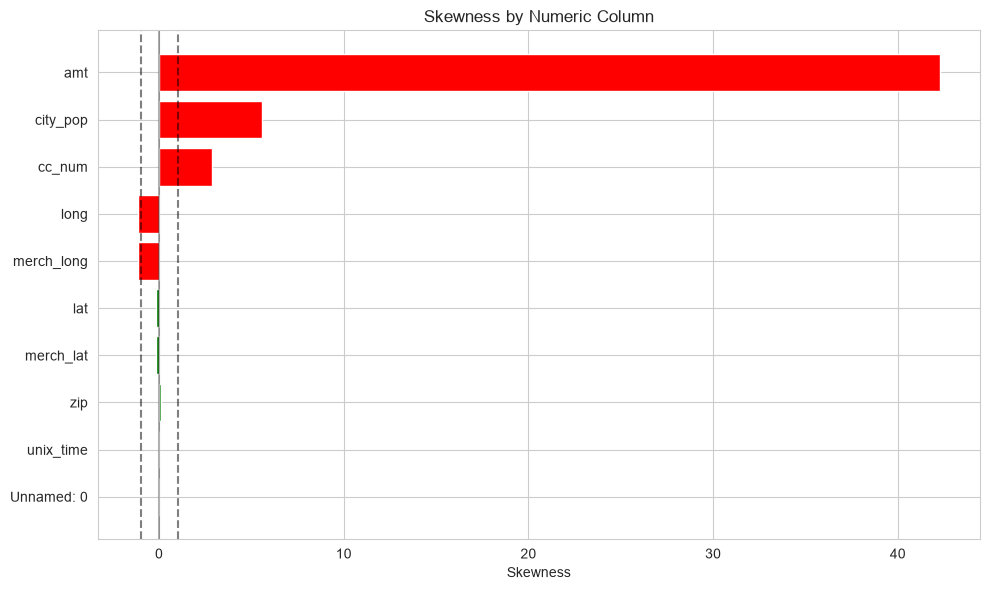

In [43]:
skew_df = num_summary[['column', 'skewness']].copy()
skew_df['abs_skew'] = skew_df['skewness'].abs()
skew_df = skew_df.sort_values('abs_skew', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['red' if abs(s) > 1 else 'orange' if abs(s) > 0.5 else 'green'
          for s in skew_df['skewness']]
plt.barh(skew_df['column'], skew_df['skewness'], color=colors)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=-1, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Skewness by Numeric Column')
plt.xlabel('Skewness')
plt.tight_layout()
plt.show()

In [44]:
# Save summaries for reference
num_summary.to_csv('../data/numeric_summary.csv', index=False)
cat_summary.to_csv('../data/categorical_summary.csv', index=False)
print("Saved summaries to data/")

Saved summaries to data/
